In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import cv2
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras 
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report as cr
from tensorflow.keras.applications import VGG16,ResNet50, DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras import Input

from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, 
    roc_curve, auc
)

from tensorflow.keras.applications.densenet import preprocess_input
import warnings
warnings.filterwarnings("ignore")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-06-05 06:04:56.647723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780639496.828478      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780639496.880581      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780639497.287126      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780639497.287166      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780639497.287169      57 computation_placer.cc:177] computation placer alr

In [2]:
Datadirectory = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

In [3]:
classes = ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']

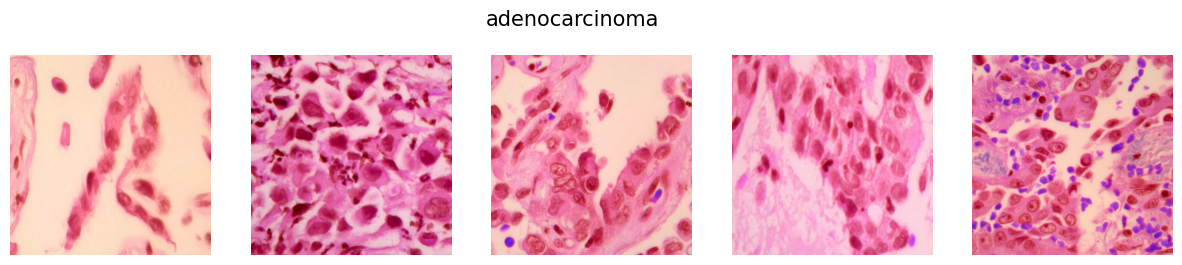

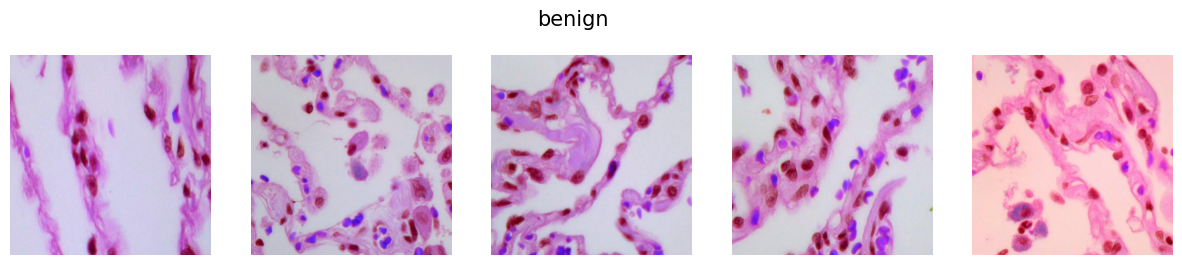

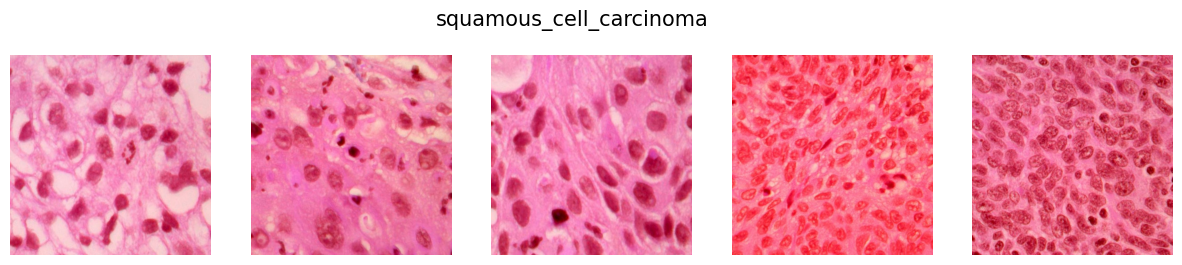

In [4]:
for cat in classes :
    path = os.path.join(Datadirectory, cat)
    images = os.listdir(path)
    fig, ax = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(5):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [5]:
datapaths = {
    "adenocarcinoma" : "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/adenocarcinoma",
    "benign":"/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/benign",
    "squamous_cell_carcinoma":"/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma"
    
}

In [6]:
def generate_df(image_dir):
    filepaths, labels = [], []
    for folder in os.listdir(image_dir):
        folder_path = os.path.join(image_dir, folder)
        for file in os.listdir(folder_path):
            filepaths.append(os.path.join(folder_path, file))
            labels.append(folder)
    return filepaths, labels


lung_fp, lung_lb   = generate_df(Datadirectory)

df = pd.DataFrame({
    "filepath":  lung_fp,
    "label":  lung_lb
})

print("Total Images:", len(df))
print(df["label"].value_counts())

Total Images: 15000
label
squamous_cell_carcinoma    5000
benign                     5000
adenocarcinoma             5000
Name: count, dtype: int64


In [7]:
#splitting the data into train and test 

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

print("Training Data :", len(train_df))
print("Testing Data  :", len(test_df))

Training Data : 13500
Testing Data  : 1500


In [8]:
img_height = 224
img_width = 224

batch_size = 32 

#creating Imagedatagenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    validation_split=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

#loading the trainning data 
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col = "filepath",
    y_col = 'label',
    target_size = (img_height,img_width),
    batch_size = 32,
    class_mode = "categorical",
    subset = "training",
    shuffle=True
)

#loading the validation data
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    target_size = (img_height,img_width),
    x_col = "filepath",
    y_col = 'label',
    batch_size = 32,
    class_mode = "categorical",
    subset = "validation",
    shuffle=False
)

#loading data for test 
test_generator= test_datagen.flow_from_dataframe(
    test_df,
    target_size = (img_height, img_width),
    x_col = "filepath",
    y_col = 'label',
    batch_size = 32,
    class_mode = "categorical",
    shuffle = False
)

Found 10800 validated image filenames belonging to 3 classes.
Found 2700 validated image filenames belonging to 3 classes.
Found 1500 validated image filenames belonging to 3 classes.


In [9]:
base_model = DenseNet121(weights='imagenet',include_top = False,input_shape=(img_height,img_width,3))

I0000 00:00:1780639551.132089      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780639551.138045      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
base_model.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [11]:
trimmedbase_model= tf.keras.Model(inputs=base_model.input, outputs=base_model.get_layer('pool2_pool').output)

In [12]:
model = Sequential([
    trimmedbase_model,
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(3, activation = 'softmax')
])

In [13]:
callbacks = [
    EarlyStopping(
        monitor = "val_loss",
        patience = 5,
        restore_best_weights = True
    ),

    ReduceLROnPlateau(
        monitor = "val_loss",
        patience = 3,
        factor  = 0.3,
        verbose = 1
    ),
    ModelCheckpoint(
        filepath = "best_DenseNet121_models.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
        )
]

In [14]:
model.compile(optimizer=Adam(learning_rate = 1e-4),loss = "categorical_crossentropy",metrics=['accuracy'])

In [16]:
history = model.fit(train_generator,epochs = 50,validation_data= validation_generator,callbacks = callbacks)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.8830 - loss: 0.3255
Epoch 1: val_loss improved from inf to 0.24471, saving model to best_DenseNet121_models.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 244s 722ms/step - accuracy: 0.8830 - loss: 0.3253 - val_accuracy: 0.8989 - val_loss: 0.2447 - learning_rate: 1.0000e-04
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9317 - loss: 0.1845
Epoch 2: val_loss did not improve from 0.24471
338/338 ━━━━━━━━━━━━━━━━━━━━ 196s 580ms/step - accuracy: 0.9317 - loss: 0.1845 - val_accuracy: 0.8181 - val_loss: 0.4164 - learning_rate: 1.0000e-04
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9493 - loss: 0.1369
Epoch 3: val_loss improved from 0.24471 to 0.14275, saving model to best_DenseNet121_models.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 197s 583ms/step - accuracy: 0.9493 - loss: 0.1368 - val_accuracy: 0.9374 - val_loss: 0.1427 - learning_rate: 1.0000e-04
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/s

In [17]:
model.save("lung_cancer_detection_using_DenseNet.keras")
print("Model is successfully saved")

Model is successfully saved


In [18]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 428ms/step
Accuracy  : 0.9893
Precision : 0.9897
Recall    : 0.9893
F1-Score  : 0.9893
                         precision    recall  f1-score   support

         adenocarcinoma       1.00      0.97      0.98       500
                 benign       1.00      1.00      1.00       500
squamous_cell_carcinoma       0.97      1.00      0.98       500

               accuracy                           0.99      1500
              macro avg       0.99      0.99      0.99      1500
           weighted avg       0.99      0.99      0.99      1500



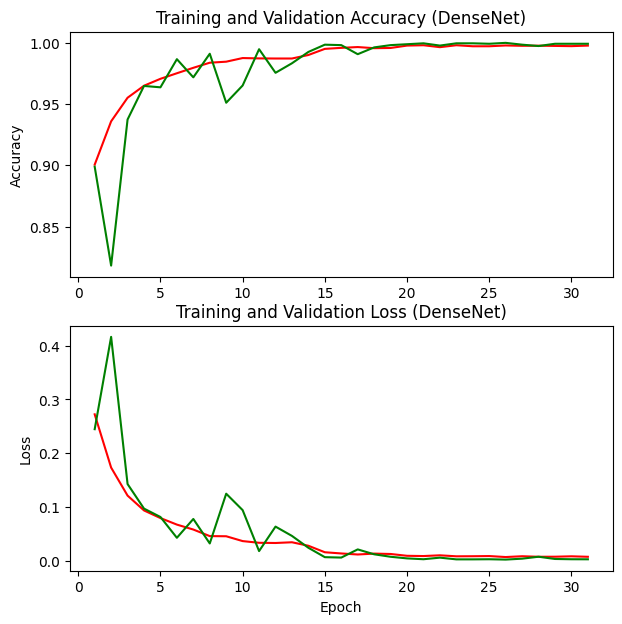

In [19]:
train_acc_2= history.history['accuracy']
val_acc_2  = history.history['val_accuracy']

train_loss_2 = history.history['loss']
val_loss_2 = history.history['val_loss']



epochs = range(1, len(history.history['val_accuracy']) + 1)

plt.figure(figsize=(7, 7))

plt.subplot(2,1,1)
plt.plot(epochs, train_acc_2, 'r-', label='Training Accuracy')
plt.plot(epochs, val_acc_2, 'g-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy (DenseNet)')
plt.ylabel('Accuracy')


plt.subplot(2,1,2)
plt.plot(epochs, train_loss_2, 'r-', label='Training loss')
plt.plot(epochs, val_loss_2, 'g-', label='Validation loss')
plt.title('Training and Validation Loss (DenseNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step


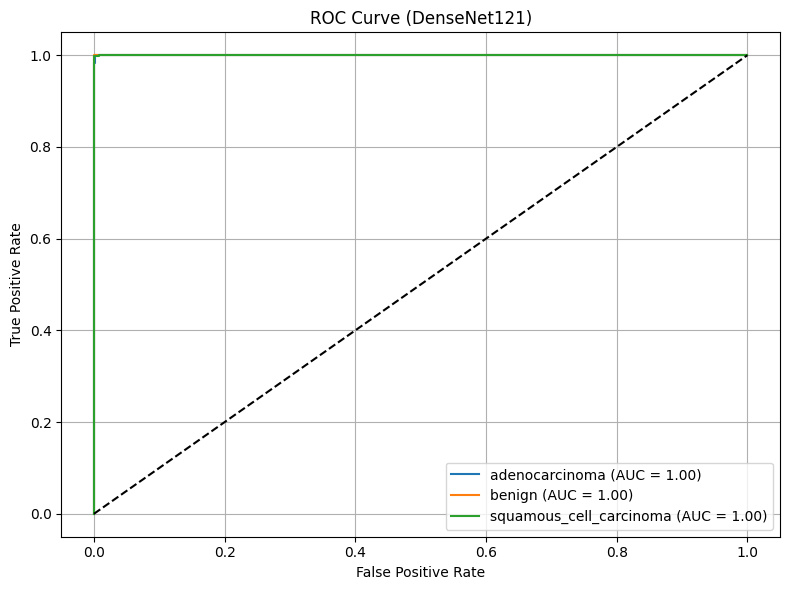

In [20]:
#ROC CURVE Densenet
n_classes = len(classes)


y_true = test_generator.classes


y_true_bin = label_binarize(y_true, classes=range(n_classes))


y_score = model.predict(test_generator)


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


# Plot ROC Curve

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Garis diagonal baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (DenseNet121)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()